**Mr. Nutthakrit Somboon (66102010167)**

**Mr. Maytuch Soradet (66102010184)**

**Mr. Ananta Sintanamongkolgul (66102010190)**

Fine tune link: https://drive.google.com/drive/folders/18wvL7GYWT4Y1ATAgAcp1joLsTg5O6-GR?usp=sharing

In [ ]:
# ===============================================================
# STEP 0: INSTALL DEPENDENCIES
# ===============================================================
print("⏳ Installing required libraries...")
import subprocess
import sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
    "transformers[sentencepiece]",
    "torch", "pillow", "accelerate",
    "peft", "bitsandbytes", "evaluate",
    "matplotlib", "sacrebleu", "lxml"
])
import torch
import os
import zipfile
from google.colab import files
from transformers import (
    BlipProcessor,
    BlipForConditionalGeneration,
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    BitsAndBytesConfig
)
from peft import PeftModel
from PIL import Image
from IPython.display import display
import evaluate
import matplotlib.pyplot as plt
import numpy as np
import zipfile, io

print("✅ Installation completed!")

⏳ Installing required libraries...
✅ Installation completed!


In [ ]:
# 1. Setup Device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"🚀 Running on: {device}")

# ---------------------------------------------------------
# ▶️ STEP 0: UPLOAD & UNZIP ADAPTER
# ---------------------------------------------------------
print("\n⬇️ Please upload your 'final_adapter' folder (ZIPPED as .zip file)...")
uploaded = files.upload()

# Get the filename of the uploaded zip
zip_filename = next(iter(uploaded))
print(f"✅ Uploaded: {zip_filename}")

# Unzip it
extract_path = "./uploaded_adapter"
print("⏳ Unzipping...")
with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Find the actual folder inside (sometimes zips have nested folders)
# We look for the folder containing 'adapter_model.safetensors' or 'adapter_model.bin'
found_adapter_path = None
for root, dirs, current_files in os.walk(extract_path): # Renamed 'files' to 'current_files'
    if "adapter_model.safetensors" in current_files or "adapter_model.bin" in current_files:
        found_adapter_path = root
        break

if found_adapter_path:
    print(f"✅ Adapter found at: {found_adapter_path}")
    adapter_folder = found_adapter_path
else:
    print("❌ ERROR: Could not find 'adapter_model.safetensors' inside the zip.")
    print("Using extraction path as fallback (might fail if structure is wrong).")
    adapter_folder = extract_path

# ---------------------------------------------------------
# ▶️ PART A: Load BLIP Captioning
# ---------------------------------------------------------
print("\n⏳ Loading BLIP captioning model...")
blip_processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-large")
blip_model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-large").to(device)
print("✅ BLIP ready")

# ---------------------------------------------------------
# ▶️ PART B: Load NLLB Base Model (8-bit) + Adapter
# ---------------------------------------------------------
model_id = "facebook/nllb-200-distilled-600M"

print("⏳ Loading NLLB tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(model_id, src_lang="eng_Latn", tgt_lang="tha_Thai")

print("⏳ Loading base 8-bit NLLB model...")
quant_config = BitsAndBytesConfig(
    load_in_8bit=True,
    llm_int8_threshold=6.0
)

base_model = AutoModelForSeq2SeqLM.from_pretrained(
    model_id,
    quantization_config=quant_config,
    device_map="auto"
)

print(f"⏳ Loading and attaching LoRA adapter from: {adapter_folder} ...")
model = PeftModel.from_pretrained(base_model, adapter_folder)
model.eval()

print("✅ All Models Ready!")

# ---------------------------------------------------------
# ▶️ PART C: Translation Function
# ---------------------------------------------------------
def translate_wrapper(text, use_finetuned=True):
    inputs = tokenizer(text, return_tensors="pt").to(device)
    thai_lang_id = tokenizer.convert_tokens_to_ids("tha_Thai")

    if use_finetuned:
        model.enable_adapter_layers()
        output_tokens = model.generate(
            **inputs,
            forced_bos_token_id=thai_lang_id,
            max_length=128
        )
    else:
        with model.disable_adapter():
            output_tokens = model.generate(
                **inputs,
                forced_bos_token_id=thai_lang_id,
                max_length=128
            )

    return tokenizer.batch_decode(output_tokens, skip_special_tokens=True)[0]

# ---------------------------------------------------------
# ▶️ PART D: Test It
# ---------------------------------------------------------
print("\n--- TEST ---")
test_sentence = "The battery life is killer."

print(f"Base Model:      {translate_wrapper(test_sentence, use_finetuned=False)}")
print(f"Fine-Tuned:      {translate_wrapper(test_sentence, use_finetuned=True)}")

🚀 Running on: cuda

⬇️ Please upload your 'final_adapter' folder (ZIPPED as .zip file)...


Saving final_adapter.zip to final_adapter (1).zip
✅ Uploaded: final_adapter (1).zip
⏳ Unzipping...


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


✅ Adapter found at: ./uploaded_adapter/final_adapter

⏳ Loading BLIP captioning model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


✅ BLIP ready
⏳ Loading NLLB tokenizer...
⏳ Loading base 8-bit NLLB model...
⏳ Loading and attaching LoRA adapter from: ./uploaded_adapter/final_adapter ...


/usr/local/lib/python3.12/dist-packages/peft/config.py:165: UserWarning: Unexpected keyword arguments ['alora_invocation_tokens', 'arrow_config', 'ensure_weight_tying', 'peft_version'] for class LoraConfig, these are ignored. This probably means that you're loading a configuration file that was saved using a higher version of the library and additional parameters have been introduced since. It is highly recommended to upgrade the PEFT version before continuing (e.g. by running `pip install -U peft`).
  warnings.warn(


✅ All Models Ready!

--- TEST ---
Base Model:      ระยะเวลาแบตเตอรี่มันน่าตาย
Fine-Tuned:      ระยะเวลาใช้งานแบตเตอรี่เป็นอันตราย



⬇️ Please upload an image to caption...


Saving OIP.jpg to OIP (7).jpg
📸 Processing: OIP (7).jpg


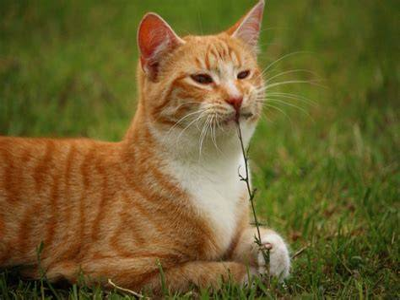


📝 Generating English caption...
✅ EN Caption: there is a cat sitting in the grass with a stick in its mouth

🌐 Translating...
🔤 English:    there is a cat sitting in the grass with a stick in its mouth
--------------------------------------------------
🧠 Base NLLB:  มีแมวนั่งในบัวไม้ในปาก
🌟 Your LoRA:  มีแมวนั่งอยู่ในหญ้าด้วยไม้ในปาก
🗑️  Deleted temporary file: 'OIP (7).jpg' (Folder is clean)


In [ ]:
# ===============================================================
# STEP 3: UPLOAD IMAGE, GENERATE CAPTION, TRANSLATE (Auto-Clean)
# ===============================================================
from PIL import Image
from IPython.display import display
from google.colab import files  # <--- IMPORT IT AGAIN HERE TO FIX THE ERROR
import os

# 1. Upload Image
print("\n⬇️ Please upload an image to caption...")
uploaded = files.upload()
img_filename = next(iter(uploaded))

print(f"📸 Processing: {img_filename}")

# 2. Open the image
image = Image.open(img_filename).convert("RGB")

# (Optional display)
display(image.resize((400, 300)))

# 3. Generate EN Caption with BLIP
print("\n📝 Generating English caption...")
# Ensure inputs are on the correct device (GPU)
inputs = blip_processor(image, return_tensors="pt").to(device)

output = blip_model.generate(**inputs, max_length=50, num_beams=5, early_stopping=True)
caption_en = blip_processor.decode(output[0], skip_special_tokens=True)

print(f"✅ EN Caption: {caption_en}")

# 4. Translate using our wrapper
print("\n🌐 Translating...")
th_base = translate_wrapper(caption_en, use_finetuned=False)
th_finetuned = translate_wrapper(caption_en, use_finetuned=True)

# 5. Show Results
print("="*50)
print(f"🔤 English:    {caption_en}")
print("-" * 50)
print(f"🧠 Base NLLB:  {th_base}")
print(f"🌟 Your LoRA:  {th_finetuned}")
print("="*50)

# ---------------------------------------------------------------
# 🚮 CLEANUP SECTION
# ---------------------------------------------------------------
if os.path.exists(img_filename):
    os.remove(img_filename)
    print(f"🗑️  Deleted temporary file: '{img_filename}' (Folder is clean)")

In [ ]:
!pip install -q evaluate sacrebleu transformers bert_score matplotlib


⏳ Loading metrics...

📝 generated EN Caption: 'there is a cat sitting in the grass with a stick in its mouth'
🧠 Base Prediction:      'มีแมวนั่งในบัวไม้ในปาก'
🌟 Finetuned Prediction: 'มีแมวนั่งอยู่ในหญ้าด้วยไม้ในปาก'

📌 Please enter the HUMAN reference translation (what it SHOULD be in Thai):
📥 Reference (Thai): มีแมวนั่งอยู่บนหญ้า

⏳ Computing scores...

✅ Evaluation complete!
🔹 BERTScore (F1) [0.0 - 1.0]:
   - Base Model:      0.8462
   - Finetuned Model: 0.9012
--------------------
🔸 chrF Score [0.0 - 100.0]:
   - Base Model:      40.79
   - Finetuned Model: 67.72


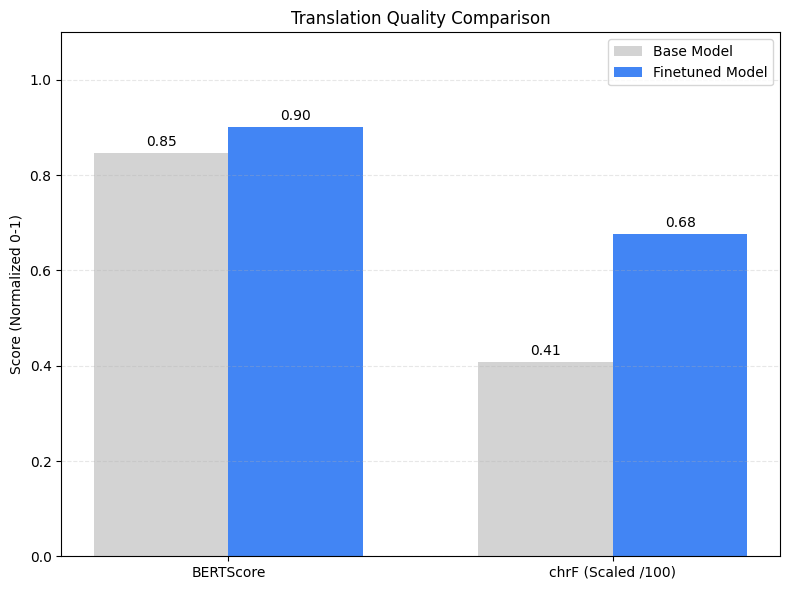

In [ ]:
# ===============================================================
# STEP 4: EVALUATE WITH BERTScore + chrF + GRAPH COMPARISON
# ===============================================================
# 2. Load Metrics
print("⏳ Loading metrics...")
bertscore = evaluate.load("bertscore")
chrf = evaluate.load("chrf")

# 3. Get Reference
# (Make sure th_base and th_finetuned exist from Step 3)
if 'th_base' not in locals() or 'th_finetuned' not in locals():
    print("❌ Error: Variables 'th_base' and 'th_finetuned' are missing.")
    print("   Please run STEP 3 first.")
else:
    print(f"\n📝 generated EN Caption: '{caption_en}'")
    print(f"🧠 Base Prediction:      '{th_base}'")
    print(f"🌟 Finetuned Prediction: '{th_finetuned}'")

    print("\n📌 Please enter the HUMAN reference translation (what it SHOULD be in Thai):")
    reference_th = input("📥 Reference (Thai): ").strip()

    if not reference_th:
        print("⛔️ No reference provided. Skipping evaluation.")
    else:
        # 4. Calculate Scores
        references = [reference_th]
        pred_base = [th_base]
        pred_tuned = [th_finetuned]

        print("\n⏳ Computing scores...")

        # BERTScore (Semantic Similarity)
        bert_base = bertscore.compute(predictions=pred_base, references=references, lang="th")
        bert_tuned = bertscore.compute(predictions=pred_tuned, references=references, lang="th")

        # chrF (Character overlap - Good for Thai)
        chrf_base = chrf.compute(predictions=pred_base, references=references)
        chrf_tuned = chrf.compute(predictions=pred_tuned, references=references)

        # Extract values
        b_score_base = bert_base['f1'][0]
        b_score_tuned = bert_tuned['f1'][0]

        c_score_base = chrf_base['score']
        c_score_tuned = chrf_tuned['score']

        # 5. Display Text Results
        print("\n✅ Evaluation complete!")
        print("="*50)
        print(f"🔹 BERTScore (F1) [0.0 - 1.0]:")
        print(f"   - Base Model:      {b_score_base:.4f}")
        print(f"   - Finetuned Model: {b_score_tuned:.4f}")
        print("-" * 20)
        print(f"🔸 chrF Score [0.0 - 100.0]:")
        print(f"   - Base Model:      {c_score_base:.2f}")
        print(f"   - Finetuned Model: {c_score_tuned:.2f}")
        print("="*50)

        # 6. Plot Comparison
        labels = ['BERTScore', 'chrF (Scaled /100)']

        # Normalize chrF to 0-1 range for plotting compatibility
        base_scores_plot = [b_score_base, c_score_base / 100]
        tuned_scores_plot = [b_score_tuned, c_score_tuned / 100]

        x = np.arange(len(labels))
        width = 0.35

        fig, ax = plt.subplots(figsize=(8, 6))
        rects1 = ax.bar(x - width/2, base_scores_plot, width, label='Base Model', color='lightgray')
        rects2 = ax.bar(x + width/2, tuned_scores_plot, width, label='Finetuned Model', color='#4285F4') # Google Blue

        ax.set_ylabel('Score (Normalized 0-1)')
        ax.set_title('Translation Quality Comparison')
        ax.set_xticks(x)
        ax.set_xticklabels(labels)
        ax.set_ylim(0, 1.1)
        ax.legend()
        ax.grid(axis='y', linestyle='--', alpha=0.3)

        # Add labels on top of bars
        ax.bar_label(rects1, fmt='%.2f', padding=3)
        ax.bar_label(rects2, fmt='%.2f', padding=3)

        plt.tight_layout()
        plt.show()